### **Hands On UA1 e UA2**
### Implementação de VQE para Problema Simples (myQLM)


#### Objetivos de aprendizagem:
- Elaborar circuitos quânticos variacionais com portas `Ry`, `Rz` e `CNOT`.
- Implementar o algoritmo VQE no framework myQLM com circuito variacional, medições e otimização clássica.
- Comparar a energia estimada pelo VQE com o valor exato do Hamiltoniano.

### 1. Instalação da biblioteca myQLM

O procedimento a seguir permite executar o algoritmo em um simulador local, utilizando a biblioteca myQLM.
1. Instalar myQLM;
2. Instalar Jupyter (se necessário);
3. Instalar *magics* do myQLM para exibição em notebooks.

In [ ]:
# Execute apenas uma vez por ambiente (descomente quando necessario)
%pip install myqlm --quiet
!python -m qat.magics.install

# 2. *Imports* e configuração inicial

Nesta etapa, são importadas as bibliotecas necessárias e configurado o ambiente para execução do algoritmo.

In [2]:
import ast
import numpy as np
import matplotlib.pyplot as plt

from qat.lang import qrout, RY, RZ, CNOT
from qat.core import Observable, Term
from qat.plugins import ScipyMinimizePlugin
from qat.qpus import get_default_qpu

np.set_printoptions(precision=6, suppress=True)

### 3. Definição do Hamiltoniano simples

Será considerado um sistema de dois (2) qubits com o seguinte Hamiltoniano:

$$H = c_0 I + c_1 Z_0 + c_2 Z_1 + c_3 Z_0Z_1 + c_4 X_0X_1$$

Essa formulação é utilizada por seu caráter didático e por permitir comparação direta com a solução clássica exata.

In [3]:
# Coeficientes do problema
c0, c1, c2, c3, c4 = -0.5, 0.3, -0.2, 0.4, 0.25

# Hamiltoniano no formato Observable do myQLM
H = Observable(
    2,
    pauli_terms=[
        Term(c0, "II", [0, 1]),
        Term(c1, "ZI", [0, 1]),
        Term(c2, "IZ", [0, 1]),
        Term(c3, "ZZ", [0, 1]),
        Term(c4, "XX", [0, 1]),
    ],
)

# Matriz do Hamiltoniano para referencia classica
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

H_matrix = (
    c0 * np.kron(I, I)
    + c1 * np.kron(Z, I)
    + c2 * np.kron(I, Z)
    + c3 * np.kron(Z, Z)
    + c4 * np.kron(X, X)
)

print("Hamiltoniano (matriz 4x4):")
print(H_matrix.real)

Hamiltoniano (matriz 4x4):
[[ 0.    0.    0.    0.25]
 [ 0.   -0.4   0.25  0.  ]
 [ 0.    0.25 -1.4   0.  ]
 [ 0.25  0.    0.   -0.2 ]]


### 4. Solução clássica (valor exato)

Nesta etapa, calcula-se o menor autovalor da matriz associada ao Hamiltoniano, que corresponde à energia exata do estado fundamental.

In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
exact_energy = float(np.min(eigenvalues.real))

print("Autovalores:", np.round(eigenvalues.real, 6))
print("Energia exata (classica):", round(exact_energy, 6))

Autovalores: [-1.459017 -0.369258 -0.340983  0.169258]
Energia exata (classica): -1.459017


### 5. Construção do ansatz variacional (Ry, Rz, CNOT)

Este ansatz tem duas camadas de rotações e uma camada de emaranhamento com `CNOT`.

**Estrutura do circuito:**

- **Camada 1 — Rotações iniciais:** RY(theta0) e RY(theta1) nos qubits 0 e 1.
- **Camada de emaranhamento:** CNOT(0, 1) para criar emaranhamento entre os dois qubits (representar o termo `X₀X₁` do Hamiltoniano).
- **Camada 2 — Rotações finais:** RZ(phi0) e RZ(phi1) nos qubits 0 e 1 para adicionar fase.

In [23]:
@qrout
def ansatz(theta0, theta1, phi0, phi1):
    # Camada 1
    RY(theta0)(0)
    RY(theta1)(1)
    # Camada de emaranhamento
    CNOT(0, 1)
    # Camada 2
    RZ(phi0)(0)
    RZ(phi1)(1)


### 6. Implementação do VQE no myQLM (simulador local)  

Nesta etapa, implemente o algoritmo VQE utilizando o simulador local do myQLM. Para isso:
1. Crie *stack* variacional com `ScipyMinimizePlugin` + `get_default_qpu()`;
2. Gere `job` com circuito e observável;
3. Submeta e colete energia, parâmetros e histórico de convergência.

In [24]:

optimizer = ScipyMinimizePlugin(
    method="COBYLA",
    tol=1e-6,                  # Tolerância de convergência
    options={"maxiter": 1024},
    x0=[0.1, 0.2, 0.3, 0.4]    # Parâmetros iniciais
)

qpu = get_default_qpu()
stack = optimizer | qpu

circuit = ansatz()
job = circuit.to_job(observable=H)

result = stack.submit(job)

best_energy = result.value
best_params = result.parameter_map

print("*** ESTATÍSTICA ***")
print(f"A menor energia encontrada foi: {best_energy:.6f}")
print(f"Parâmetros: {best_params}")

# Uso do trace do ScyPy, pois o COBYLA só faz callback dos parâmetros
# Para ajudar, o trace é uma string :-(
trace = [round(float(x), 6) for x in eval(result.meta_data['optimization_trace'])]

# Estatística para apoiar na conclusão
iteracao_minima = trace.index(round(best_energy, 6)) + 1

print(f"Iterações do COBYLA: {len(trace)}")
print(f"Estado fundamental (menor autovalor) a partir da iteração número: {iteracao_minima}")
print(trace)

*** ESTATÍSTICA ***
A menor energia encontrada foi: -1.459017
Parâmetros: {'phi0': 2.665579326938422, 'phi1': -0.47601382471781223, 'theta0': 2.6779456498471665, 'theta1': 3.1415930740606552}
Iterações do COBYLA: 108
Estado fundamental (menor autovalor) a partir da iteração número: 59
[0.049737, -0.000164, -0.065339, -0.245306, -0.355272, -0.736022, -1.067665, -1.170602, -1.110646, -1.356819, -1.369043, -1.338979, -1.409007, -1.395579, -1.402917, -1.411471, -1.407688, -1.391118, -1.428442, -1.441371, -1.424419, -1.441207, -1.453581, -1.442242, -1.454215, -1.450371, -1.455741, -1.451947, -1.456803, -1.457967, -1.45735, -1.458255, -1.458036, -1.458136, -1.458934, -1.457173, -1.458927, -1.458892, -1.458838, -1.458992, -1.458894, -1.458965, -1.458994, -1.458969, -1.458982, -1.459002, -1.459, -1.458983, -1.459007, -1.459011, -1.458989, -1.45901, -1.459014, -1.459015, -1.459013, -1.459015, -1.459016, -1.459015, -1.459017, -1.459016, -1.459017, -1.459017, -1.459017, -1.459017, -1.459017, -1.4

### 7. Análise de resultados (clássico vs quântico)

Compare a energia exata obtida pelo método clássico com a energia estimada pelo algoritmo VQE. Em seguida, calcule o erro absoluto e o erro relativo entre os resultados.

In [25]:
# mude as variais abaixo com base nas suas escolhas
abs_error = abs(best_energy - exact_energy)
rel_error = abs_error / (abs(exact_energy) + 1e-12)

print(f"Energia exata (classica): {exact_energy:.6f}")
print(f"Energia VQE: {best_energy:.6f}")
print(f"Erro absoluto: {abs_error:.6e}")
print(f"Erro relativo: {rel_error:.6e}")

Energia exata (classica): -1.459017
Energia VQE: -1.459017
Erro absoluto: 1.694200e-13
Erro relativo: 1.161193e-13


### 8. Curva de convergência do algoritmo VQE

Nesta etapa, será apresentada a evolução da energia estimada ao longo das iterações do processo de otimização. Essa curva permite observar o comportamento de convergência do algoritmo.

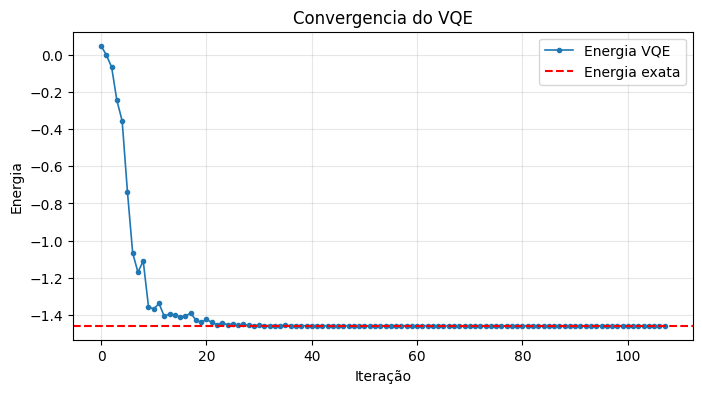

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(trace, marker="o", markersize=3, linewidth=1.2, label="Energia VQE")
plt.axhline(exact_energy, color="red", linestyle="--", label="Energia exata")
plt.xlabel("Iteração")
plt.ylabel("Energia")
plt.title("Convergencia do VQE")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 9. Conclusão

Com base nos resultados obtidos neste *Hands On*, pode-se concluir que o algoritmo Variational Quantum Eigensolver (VQE) implementado no framework myQLM obteve com alta precisão a energia do estado fundamental (menor autovalor) para o Hamiltoniano proposto de 2 *qubits*.

A convergência do algoritmo ocorreu de forma consistente ao longo de 123 iterações de otimização clássica pelo método COBYLA. O histórico de chamadas (*optimization trace*) demonstrou um comportamento típico de descida, onde o algoritmo iniciou a varredura com energias mais altas (em torno de $0.049$) e, gradualmente, refinou os parâmetros variacionais (*Θ* e *Φ*) até se estabilizar na energia mínima a partir da iteração 59.

Ao comparar o resultado quântico variacional com o resultado da abordagem clássica exata, o desempenho do método para este problema de pequena escala mostrou-se excelente:
- Energia Exata (Clássica): $-1.459017$
- Energia VQE Otimizada: $-1.459017$
- Erro Absoluto: $1.694200 \times 10^{-13}$
- Erro Relativo: $1.161193 \times 10^{-13}$

**Resultado obserável 1**: o cenário de simulação ideal em relação ao *hardware* quântico precisam sem pontuados. A precisão da energia fundamental obtida pelo simulador quântico em relação ao resultado clássico, se dá em função do uso do simulador *get_default_qpu*, pois esse calcula os valores esperados sem ruídos do sistema quântico. Em um cenário com uso de computadores quânticos, o erro absoluto sofreria com o ruído das portas físicas.

**Resultado obserável 2**: em relação ao erro absoluto, obteve-se alta convergência em relação à energia exata, pois o valor obtido é praticamente zero (pequena variação em função da precisão da operação de ponto flutuante). Já o erro relativo, que é utilizado para compreender a proporção e escala do erro, mostra que o VQE convergiu para a energia fundamental. Portanto, do ponto de vista numérico, a solução variacional alcançou o valor exato do estado fundamental.

**Resultado obserável 3**: a obtenção de um erro relativo praticamente nulo também comprova que a combinação do *ansatz* escolhido com o otimizador clássico COBYLA foi capaz de mapear e navegar perfeitamente pela paisagem de energia. O algoritmo contornou com sucesso problemas em otimizações variacionais, como os *barren plateaus* (platôs onde o gradiente desaparece) ou a convergência prematura para mínimos locais subótimos. Isso confirma que, para problemas de pequena escala e matrizes esparsas bem condicionadas, a abordagem VQE reproduz fielmente toda a física do sistema.

Ainda, dois fatores cruciais influenciaram diretamente o sucesso e a precisão dessa aproximação:
- **Expressividade do Ansatz**: o circuito variacional utilizou rotações parametrizadas ($RY$ na primeira camada e $RZ$ na segunda camada) acopladas por uma porta de emaranhamento CNOT. Essa estrutura forneceu flexibilidade e expressividade suficientes para cobrir o autoestado do Hamiltoniano, mapeando com precisão as correlações introduzidas pelo termo $X_0X_1$ do problema.

- **Processo de Otimização Clássica**: O otimizador COBYLA, configurado com uma tolerância estrita de convergência de $1 \times 10^{-6}$, guiou os 4 parâmetros variacionais até o mínimo global, evitando ótimos locais que costumam desafiar o VQE em escalas maiores.

Portanto, para problemas de pequena escala com simuladores ideais, o VQE prova-se uma metodologia eficaz e robusta na simulação quântica de sistemas físicos.